# Malicious URL detection Notebook

## Loading Dataset

In [11]:
import pandas as pd

df = pd.read_csv(f'dataset\phishing_site_urls.csv')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549346 entries, 0 to 549345
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   URL     549346 non-null  object
 1   Label   549346 non-null  object
dtypes: object(2)
memory usage: 8.4+ MB


In [21]:
df.count()

URL      549346
Label    549346
dtype: int64

In [ ]:
df_cleaned = df.drop_duplicates()

In [53]:
df['Label'].value_counts()

Label
good    392924
bad     156422
Name: count, dtype: int64

In [57]:
df_cleaned['Label'].value_counts()

Label
good    392897
bad     114299
Name: count, dtype: int64

In [ ]:
bad_sites = df_cleaned[df_cleaned['Label'] == 'bad']
good_sites = df_cleaned[df_cleaned['Label'] == 'good']

# 3. Sample 5,000 from each
# random_state=42 ensures we get the same random 5k every time we run this
bad_sample = bad_sites.sample(n=5000, random_state=5)
good_sample = good_sites.sample(n=5000, random_state=5)

# 4. Combine them back into one dataframe
balanced_df = pd.concat([bad_sample, good_sample])

# 5. Shuffle the rows (Critical step!)
# frac=1 means return 100% of the rows, but in random order
balanced_df = balanced_df.sample(frac=1, random_state=5).reset_index(drop=True)

# 6. Convert labels to numbers
# 'bad' -> 1, 'good' -> 0
balanced_df['Label'] = balanced_df['Label'].map({'bad': 1, 'good': 0})

print(f"New dataset shape: {balanced_df.shape}")
print(balanced_df['Label'].value_counts())


New dataset shape: (10000, 2)
Label
0    5000
1    5000
Name: count, dtype: int64


In [87]:
balanced_df['URL'].isna().sum()

0

In [95]:
# safe URLS sample
balanced_df[balanced_df['Label']==0].head()

,URL,Label
0,members.tripod.com/frank_mclean/resume/index.html,0
5,tripadvisor.com/Tourism-g186216-United_Kingdom...,0
6,mstmicro.com/saver/index.html,0
7,expedia.com/Jarry-Park-Hotels.0-l6072573-0.Tra...,0
10,stgeorgesanglicanchurch.org/anglican.htm,0


## Investigating the https and http problem in the dataset

In [21]:
containing_http = balanced_df[balanced_df['URL'].str.contains("http://", na=False)]['URL']
print("URLs containing http:// --> ",containing_http.count())

URLs containing http:// -->  37


In [45]:
containing_http

47      two.hfdodiopr.biz/43kdiu8322\ndkoawit6.com/ik/...
222     hkguohui.com/js/?http://us.battle.net/login/en...
392     kf25zx.com/images?ref=http://xcqdlhtus.battle....
464                    http://dizayn74.com/images/42,032/
633     http://s70.n57.n84.n66.static.myhostcenter.com...
712     51jianli.cn/images/?http://us.battle.net/login...
802     kf25zx.com/images/?http://us.battle.net/login/...
991     vpv.cn/js/?app=com-d3&amp;http://us.battle.net...
1127        51mct.com/js/?http://us.battle.net/login/en/=
1311    xjbctcky.com/images/?ref=http://us.battle.net/...
1344    bjcurio.com/js/index.htm?http://us.battle.net/...
2159    shshide.com/js?.randInboxLight.aspx?n74256418=...
2180    bjcurio.com/js/index.htm?http://us.battle.net/...
2782      xjbctcky.com/images/?http://us.battle.net/login
3658    cnhedge.cn/js/index.htm?http://us.battle.net/l...
3703    ysgrp.com.cn/js?us.battle.net/login/en/?ref=ht...
3881    bjcurio.com/js/index.htm?ref=http://izrxueeus....
4068    vast.b

In [47]:
containing_https = balanced_df[balanced_df['URL'].str.contains("https://", na=False)]['URL']
print("URLs containing https:// --> ",containing_https.count())

URLs containing https:// -->  8


In [55]:
containing_https_list = containing_https.tolist()
for i, url in enumerate(containing_https_list):
    print(f"{i+1} - ", url)

1 -  https://onedrive.live.com/redir?page=survey&amp;resid=28AC22BC0A9F0CD1!116&amp;authkey=!AP5T0Ygdo03uqC4&amp;ithint=file,xlsx
2 -  redhongan.com/js/?https://secure.runescape.com/m=weblogin/loginform.ws?mod=www
3 -  zjgsyds.cn/js/?https://secure.runescape.com/m=weblogin/
4 -  mister-ed.com/welcome/file/update/rbc/login.php?https://www1.royalbank.com/cgi-bin/rbaccess/rbunxcgi?F6=1
5 -  zjgsyds.cn/js/?dest&amp;ehozeyhssl=0&amp;https://secure.runescape.com/m=weblogin/
6 -  nullrefer.com/?https://www.cartalis.it/cartalis/prepagata/index.jsp
7 -  cpbrandindia.com/https://atendimento/chama.php?=I6MBLRZ45IY1QEZMW99C8NLH0O8YZPGIV3TGUTJZBIZ3XYPT8Y7ELRWUG5TFT0XPCR67LP6X85Z64PYAN6P9WM4DQWSK7Q0IIFO45U1CZ1H4QGDDL4MIQPVGMO2SFBAXQZ2UU38T4PWT7A7RETA5I7K6VMXAX99N90I3CQWFFS9L4EDH9OLQU7VPTT1Q29E0HXBTN8941HO5W3M5Q9ULFQB9JBZLJDU2A7VYE52FLQKHS7LJFG6U7G4QR3BAG7CRD8PSBQ8WGRE0YZTDFY9MFBC7EOHUVTL92B1C290I1NSYNLC3KKPZW27AQN6LHRTI3UV535M3SE2F1EIKZ8KV0Q71EBLV3FE6A00CEVF8AHNBV6WVDGRN8XOL00GCPVHZ5QCJMRQX0D95J61XL

In [43]:
# containing_http_list = containing_http.tolist()
# for url in containing_http_list:
#     print("- ", url)

## Feature extraction

In [281]:
import re
from urllib.parse import urlparse

def extract_features(url):
    url = str(url)
    # If the URL doesn't start with http or https, assume it needs http://
    # This forces urlparse to recognize the domain part.
    if not url.startswith(('http://', 'https://')):
        url = 'http://' + url

    try:
        parsed = urlparse(url)
        hostname = parsed.netloc
        
        # IMPROVEMENT: Handle ports (e.g., 192.168.1.1:8080)
        # If we don't remove :8080, the IP regex will fail.
        if ':' in hostname:
            hostname = hostname.split(':')[0]
            
        path = parsed.path
    except:
        hostname = ""
        path = ""

    features = []
    features.append(len(url))          # --- Feature 1: Length of URL
    features.append(len(hostname))     # --- Feature 2: Length of Hostname
    features.append(url.count('.'))    # --- Feature 3: Count of Dots
    features.append(url.count('-'))    # --- Feature 4: Count of Hyphens
    features.append(url.count('@'))    # --- Feature 5: Count of '@' 
    features.append(url.count('?'))    # --- Feature 6: Count of '?'
    features.append(sum(c.isdigit() for c in url))   # --- Feature 7: Count of Digits
    # --- Feature 8: Presence of IP Address in Hostname
    # Updated Regex to be slightly more robust
    ip_pattern = r"^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}$"
    has_ip = 1 if re.match(ip_pattern, hostname) else 0
    features.append(has_ip)

    return features

In [ ]:
print("Extracting features... this might take a moment.")

# Applying the function to the 'URL' column
# This creates a Series where every row is a list of features: [23, 15, 2, ...]
feature_lists = balanced_df['URL'].apply(extract_features)

# Converting that Series of lists into a proper DataFrame with named columns
X = pd.DataFrame(feature_lists.tolist(), columns=[
    'url_length', 
    'hostname_length', 
    'dot_count', 
    'hyphen_count', 
    'at_count', 
    'question_count', 
    'digit_count', 
    'has_ip'
])

# Defining target (y)
y = balanced_df['Label']

# Checking the result
print("Feature extraction complete.")
print(X.head())

Extracting features... this might take a moment.
Feature extraction complete.
   url_length  hostname_length  dot_count  hyphen_count  at_count  \
0          56               18          3             0         0   
1          67               25          3             1         0   
2         108               22          2             4         0   
3          36               21          2             0         0   
4          80               13          2             0         0   

   question_count  digit_count  has_ip  
0               0            0       0  
1               0            0       0  
2               1           26       0  
3               0            0       0  
4               1            0       0  


In [297]:
test = X[X['has_ip'] == 0]
len(test)
# len(balanced_df)

9859

## EDA

In [300]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Combine X (features) and y (label) back together for plotting
eda_df = X.copy()
eda_df['Label'] = y

# 2. Rename label 0/1 to 'Safe'/'Malicious' for easier reading in graphs
eda_df['Label_Str'] = eda_df['Label'].map({0: 'Safe', 1: 'Malicious'})

print("Data ready for plotting.")

Data ready for plotting.


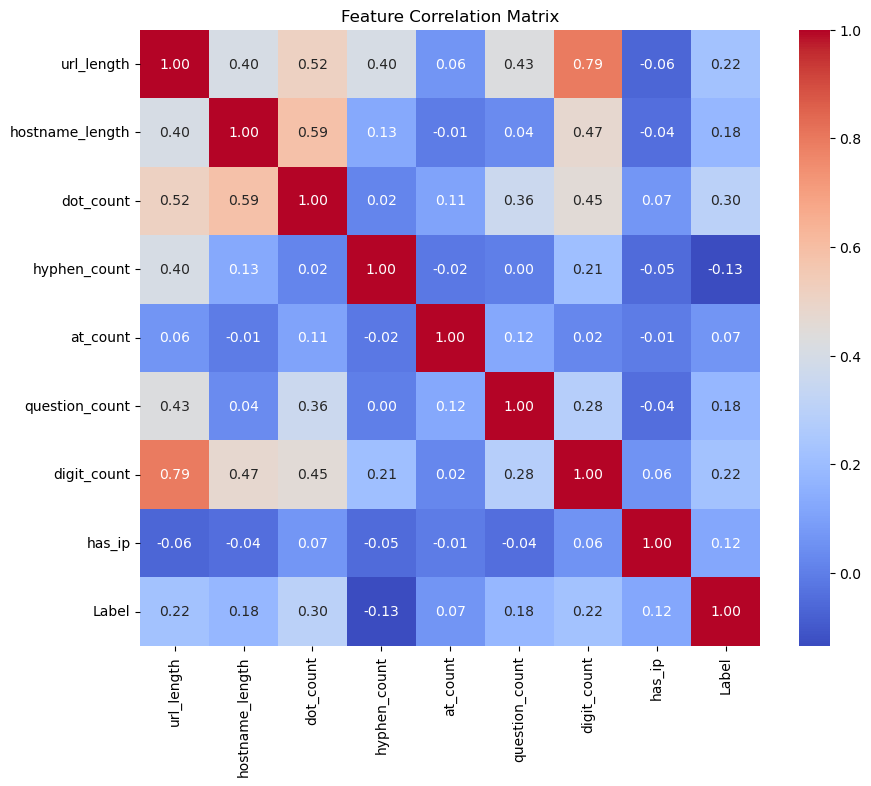

In [302]:
plt.figure(figsize=(10, 8))
# Calculate correlation matrix
corr = eda_df.drop(columns=['Label_Str']).corr()
# Plot heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

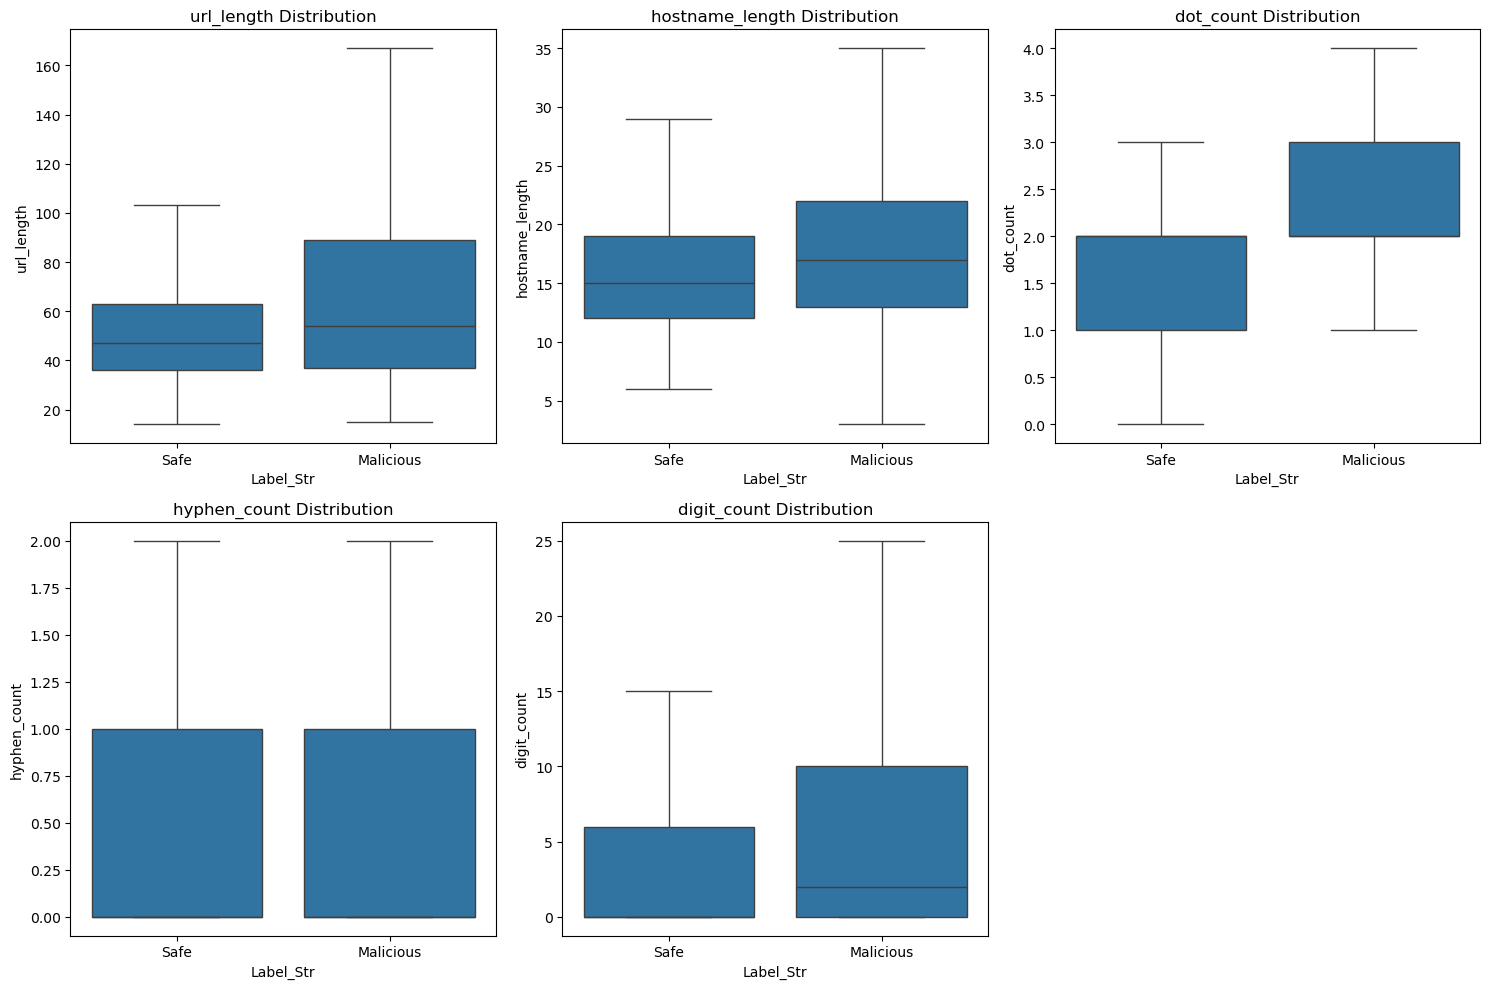

In [304]:
# List of features to check (exclude the Label itself)
features_to_plot = ['url_length', 'hostname_length', 'dot_count', 
                    'hyphen_count', 'digit_count']

plt.figure(figsize=(15, 10))

for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 3, i+1) # Create a grid of small plots
    
    # x=Label_Str splits the data into two side-by-side boxes
    # y=feature maps the height of the box to the feature value
    sns.boxplot(x='Label_Str', y=feature, data=eda_df, showfliers=False)
    
    plt.title(f"{feature} Distribution")

plt.tight_layout()
plt.show()

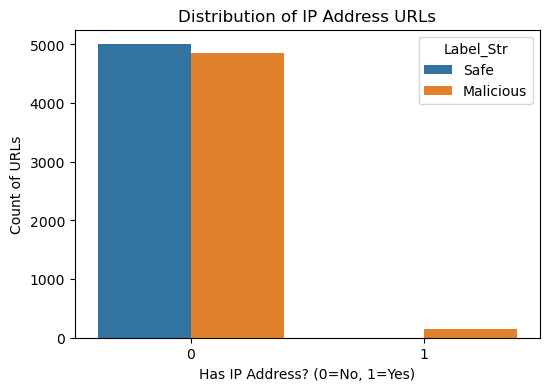

In [306]:
plt.figure(figsize=(6, 4))
sns.countplot(x='has_ip', hue='Label_Str', data=eda_df)
plt.title("Distribution of IP Address URLs")
plt.xlabel("Has IP Address? (0=No, 1=Yes)")
plt.ylabel("Count of URLs")
plt.show()

(0.0, 300.0)

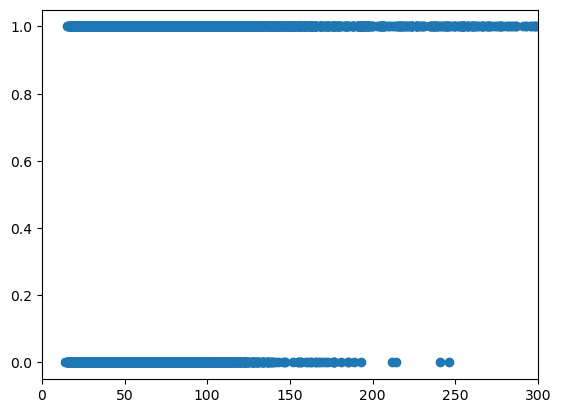

In [364]:
plt.scatter(eda_df['url_length'], eda_df['Label'])
plt.xlim(0, 300) # Limit x-axis to zoom in (ignore extreme outliers)

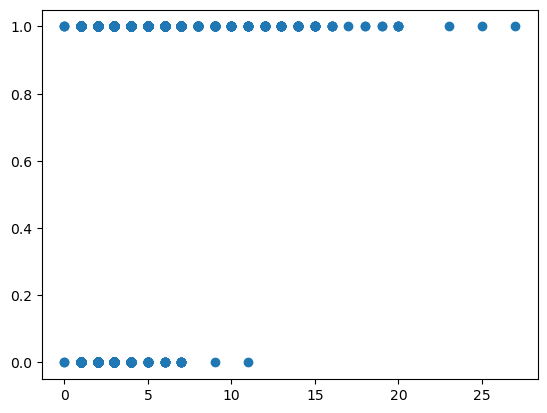

In [312]:
plt.scatter(eda_df['dot_count'], eda_df['Label'])

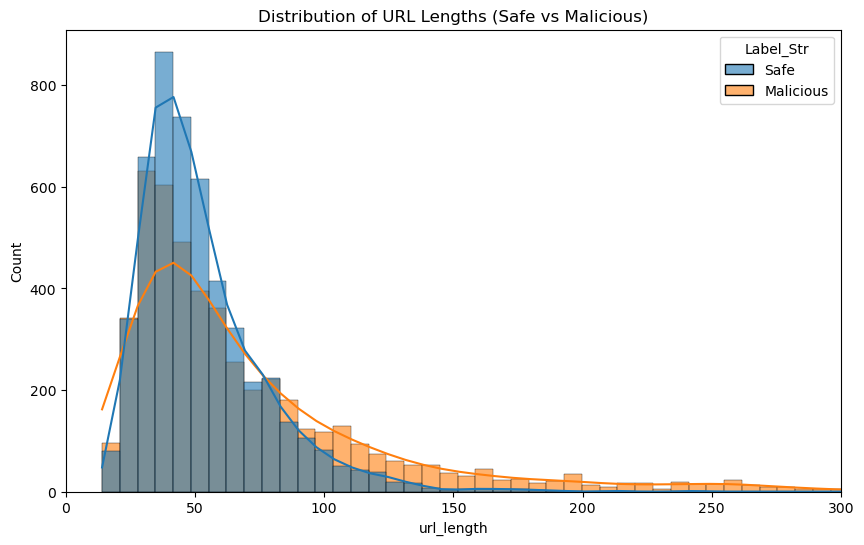

In [358]:
plt.figure(figsize=(10, 6))

# distinct colors for 0 and 1
sns.histplot(data=eda_df, x='url_length', hue='Label_Str', 
             kde=True, bins=200, alpha=0.6)

plt.title("Distribution of URL Lengths (Safe vs Malicious)")
plt.xlim(0, 300) # Limit x-axis to zoom in (ignore extreme outliers)
plt.show()

## scaling the data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# 1. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

# 2. Initialize RobustScaler
# This uses the Median instead of the Mean
scaler = RobustScaler()

# 3. Fit and Transform
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Robust Scaling complete. Outliers preserved but neutralized.")

Robust Scaling complete. Outliers preserved but neutralized.


## building the model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

# 1. Building and Training the Model
# n_estimators=100 means we build 100 decision trees and vote on the result
rf_model = RandomForestClassifier(n_estimators=300, random_state=5)
rf_model.fit(X_train_scaled, y_train)


RandomForestClassifier(n_estimators=300, random_state=5)

## Evaluation

In [ ]:
# 2. Make Predictions
y_pred = rf_model.predict(X_test_scaled)

# Get the probability (e.g., 0.85 chance of being malicious) for the ROC plot
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# 3. Text Evaluation
print(f"Global Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Global Accuracy: 0.7590


In [378]:
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Safe', 'Malicious']))


--- Detailed Classification Report ---
              precision    recall  f1-score   support

        Safe       0.74      0.79      0.76       982
   Malicious       0.78      0.73      0.75      1018

    accuracy                           0.76      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.76      0.76      0.76      2000



## Plots for evaluation

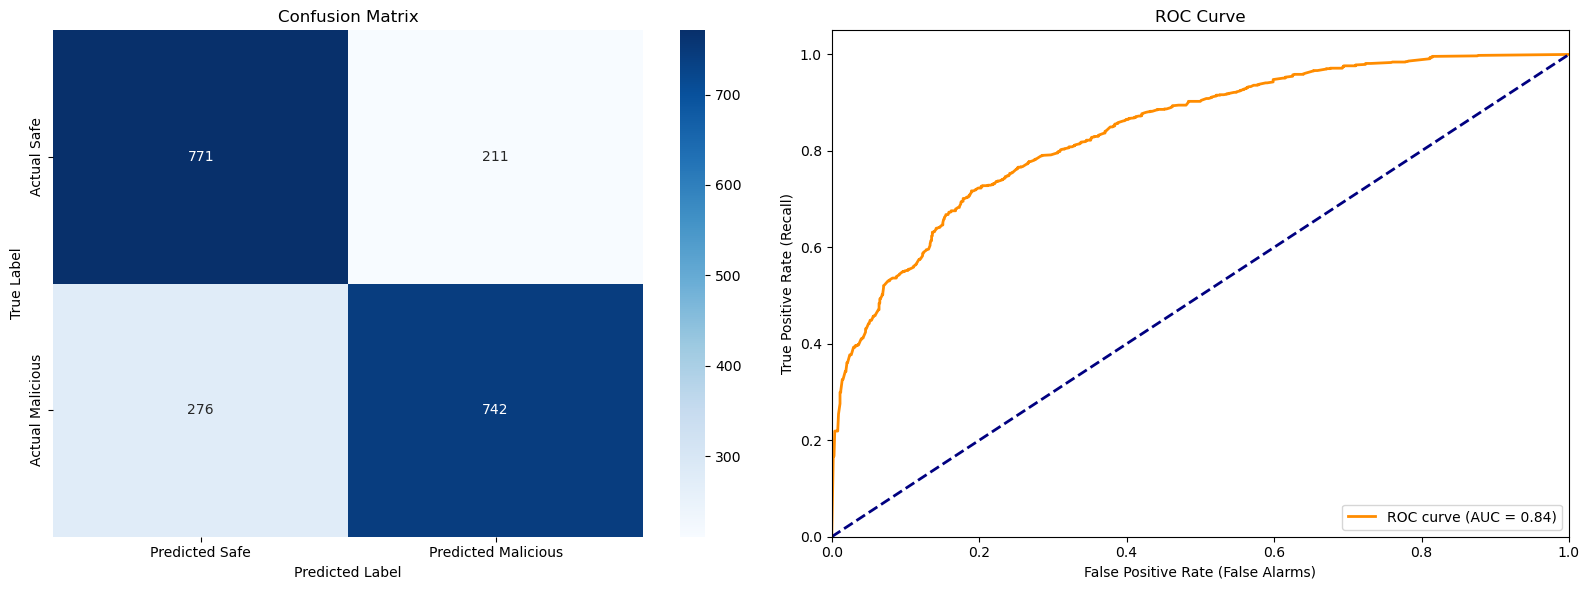

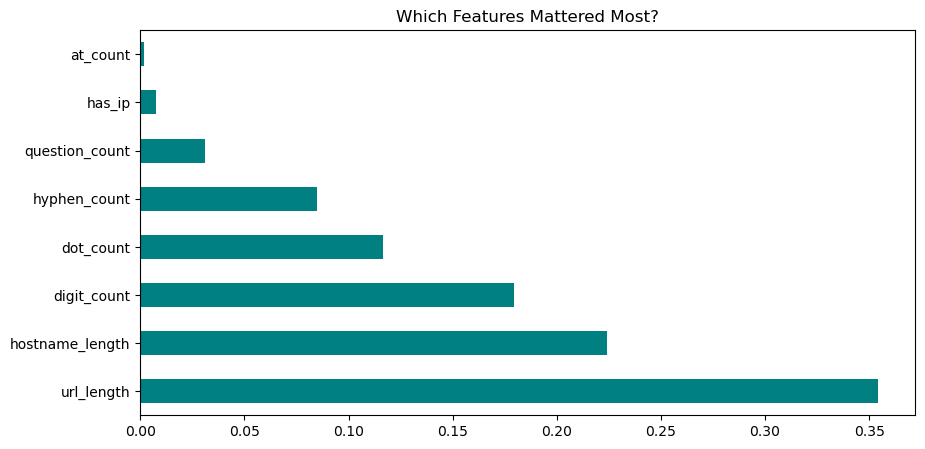

In [ ]:
# 4. Plotting Evaluation
# Creating a figure with 2 side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Predicted Safe', 'Predicted Malicious'],
            yticklabels=['Actual Safe', 'Actual Malicious'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot B: ROC Curve (Receiver Operating Characteristic)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # The random guess line
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (False Alarms)')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# Feature Importance Plot
# This shows exactly which features the model found most useful
plt.figure(figsize=(10, 5))
importances = rf_model.feature_importances_
# Creating a pandas series for easy plotting
import pandas as pd
feat_importances = pd.Series(importances, index=X_train_scaled.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("Which Features Mattered Most?")
plt.show()

## Advanced model using addition features extracted from the url text using Tfidf

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# 1. Setup the Data (Assume 'X' has numeric features + a column 'url_text')
# We need to make sure X contains the raw URL string column for TF-IDF
X_hybrid = X.copy()
X_hybrid['url_text'] = balanced_df['URL'] # Add raw URL back for text processing

# Split
X_train, X_test, y_train, y_test = train_test_split(X_hybrid, y, test_size=0.2, random_state=42)

# 2. Define the Preprocessing Pipeline
# Branch A: Handle the text (The Raw URL)
text_features = 'url_text'
text_transformer = TfidfVectorizer(analyzer='char', ngram_range=(3, 5), max_features=5000)

# Branch B: Handling the numbers (The features you already built)
numeric_features = ['url_length', 'hostname_length', 'dot_count', 'hyphen_count', 
                    'at_count', 'question_count', 'digit_count', 'has_ip']
numeric_transformer = RobustScaler()

# Combining them
preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_transformer, text_features),
        ('num', numeric_transformer, numeric_features)
    ])

# 3. Creating the Full Pipeline (Preprocessing + Model)
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 4. Defining Grid Search Parameters
param_grid = {
    'classifier__n_estimators': [100, 200], # Kept small for speed demo, try 300+ for real
    'classifier__max_depth': [None, 30],
    'classifier__min_samples_split': [2, 5]
}

# 5. Run Grid Search
print("Starting Grid Search... this takes time because we are analyzing text now.")
grid_search = GridSearchCV(pipeline, param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# 6. Evaluate
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"\nBest Params: {grid_search.best_params_}")
print(f"New Global Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Starting Grid Search... this takes time because we are analyzing text now.
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best Params: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
New Global Accuracy: 0.9080


In [442]:
print("mean validation accuracy: ", grid_search.best_score_)

mean validation accuracy:  0.9040007002125484


In [438]:
best_model.predict_proba(X_test)[:,1]

array([0.155, 0.825, 0.845, ..., 0.02 , 0.68 , 0.295])

## Evaluation visulaization

In [ ]:
# 1. Use the best model from Grid Search
# Ensure X_test contains both the numeric columns AND the 'url_text' column
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# 2. Print Text Report
print(f"Global Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Safe', 'Malicious']))

Global Accuracy: 0.9080

--- Classification Report ---
              precision    recall  f1-score   support

        Safe       0.90      0.93      0.91      1013
   Malicious       0.92      0.89      0.91       987

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000



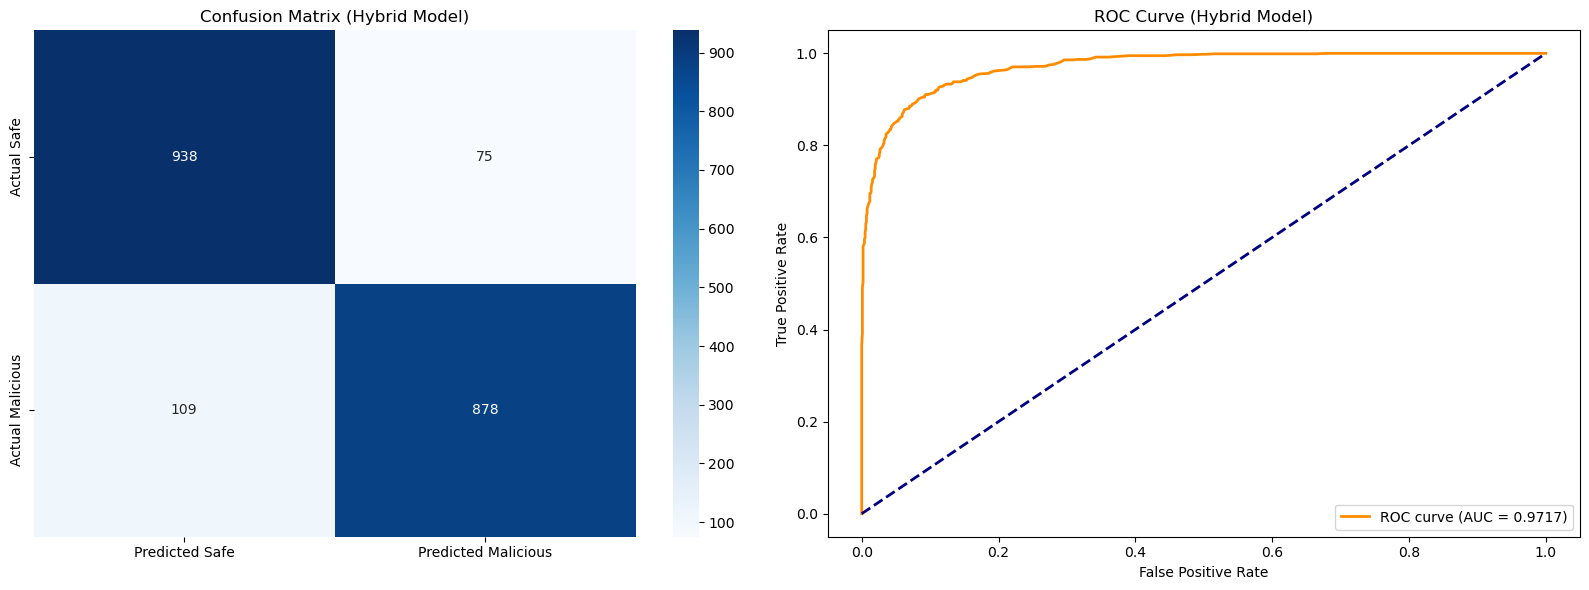

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Predicted Safe', 'Predicted Malicious'],
            yticklabels=['Actual Safe', 'Actual Malicious'])
axes[0].set_title('Confusion Matrix (Hybrid Model)')

# Plot B: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Hybrid Model)')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## Saving the whole pipeline(data scaling + Tfidf feature extraction + prediction)

In [ ]:
import joblib

# 'best_model' is the winner from GridSearch
# It contains: [TfidfVectorizer, RobustScaler, RandomForest]
joblib.dump(best_model, 'phishing_detection_pipeline.pkl')

print("Model saved successfully!")

Model saved successfully!
